# Setup

In [1]:
!git clone https://github.com/ronalabrcns/DuckSeg

Cloning into 'DuckSeg'...
remote: Enumerating objects: 174, done.
remote: Counting objects: 100% (131/131), done.
remote: Compressing objects: 100% (89/89), done.
remote: Total 174 (delta 67), reused 91 (delta 36), pack-reused 43 (from 3)
Receiving objects: 100% (174/174), 114.25 MiB | 17.19 MiB/s, done.
Resolving deltas: 100% (73/73), done.
Updating files: 100% (37/37), done.


In [2]:
!pip install git+https://github.com/vanvalenlab/cellSAM.git@362a8e521bcd7313d5cb280bcd4cfc12977c1e9f
!pip install nd2

  Cloning https://github.com/vanvalenlab/cellSAM.git (to revision 362a8e521bcd7313d5cb280bcd4cfc12977c1e9f) to /tmp/pip-req-build-sk27ncln
  Running command git clone --filter=blob:none --quiet https://github.com/vanvalenlab/cellSAM.git /tmp/pip-req-build-sk27ncln
  Running command git rev-parse -q --verify 'sha^362a8e521bcd7313d5cb280bcd4cfc12977c1e9f'
  Running command git fetch -q https://github.com/vanvalenlab/cellSAM.git 362a8e521bcd7313d5cb280bcd4cfc12977c1e9f
  Resolved https://github.com/vanvalenlab/cellSAM.git to commit 362a8e521bcd7313d5cb280bcd4cfc12977c1e9f
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Cloning https://github.com/facebookresearch/segment-anything.git to /tmp/pip-install-bvhfsspx/segment-anything_959f43fc723c4f789848a7948532a68f
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /tmp/pip-install-bvhfsspx/segme

In [3]:
!pip install ipympl --quiet
get_ipython().kernel.do_shutdown(restart=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.0/519.0 kB 44.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 135.8 MB/s eta 0:00:00


{'status': 'ok', 'restart': True}

> Wait until session reconnects!

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('./DuckSeg/src'))

In [2]:
import numpy as np
import torch
from scipy.ndimage import binary_dilation
import matplotlib.pyplot as plt
import cv2

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device type {device.type}")

Device type cuda


In [4]:
from google.colab import userdata

# Fetch from Colab Secrets and set as a system environment variable
os.environ['DEEPCELL_ACCESS_TOKEN'] = userdata.get('DEEPCELL_ACCESS_TOKEN')

# Loading experiment data

In [5]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [6]:
# Modify these to load experiment data from a directory
data_dir = "/content/drive/MyDrive/cell_segmentation/videos/MSH2/EV_siUTR"
name = "MSH2"

In [7]:
from DuckSeg.experiment_loader import ExperimentBatch
batch = ExperimentBatch(name, data_dir)
print(f"Number of experiments in batch: {len(batch.experiments())}")

Number of experiments in batch: 4


## Calculate minumum number of frames for the experiments in the batch

In [8]:
lens = []
for experiment in batch.experiments():
    lens.append(len(experiment.frames_u8()))
min_len = min(lens)
max_len = max(lens)
batch.max_len = min_len
print(f"Minimum number of frames {min_len}")
print(f"Maximum number of frames {max_len}")

Minimum number of frames 122
Maximum number of frames 242


# ROI Editor

Interactive editor for correcting ROI boundaries. Drag the black lines up/down to adjust ranges; changes are saved automatically next to the original ROI file.

In [9]:
from google.colab import output
output.enable_custom_widget_manager()

%matplotlib widget
from DuckSeg.roi_editor import show_roi_editors
show_roi_editors(batch.experiments())

# Generating cell masks

## Config

In [10]:
from DuckSeg.image_transformer import generate_masks_using_filters_and_transforms
from DuckSeg.image_transforms import convert_to_u8, threshold_image, adjust_contrast, set_brightness

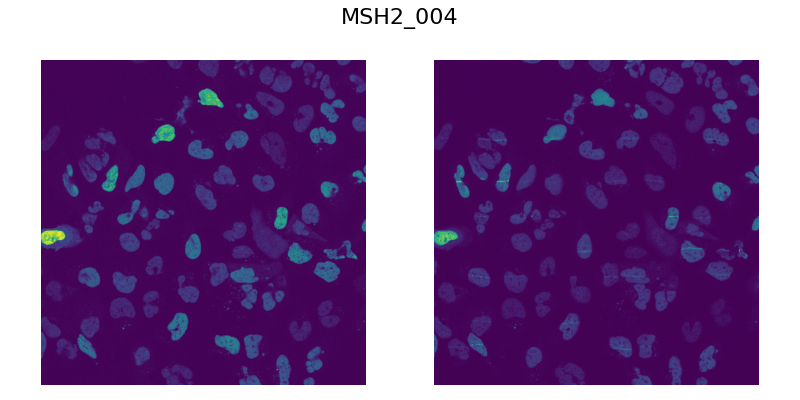

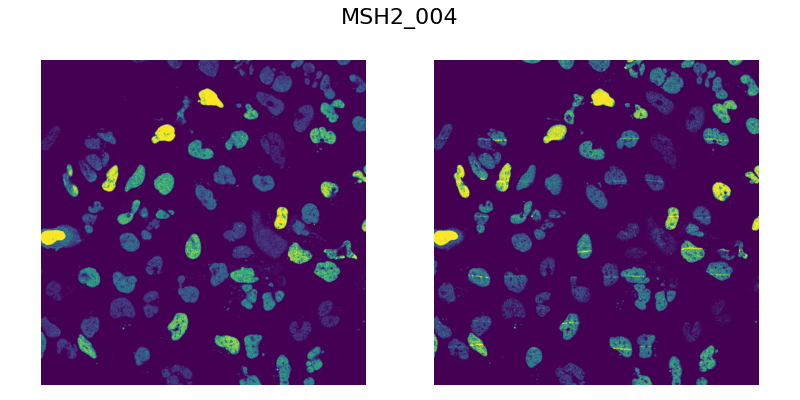

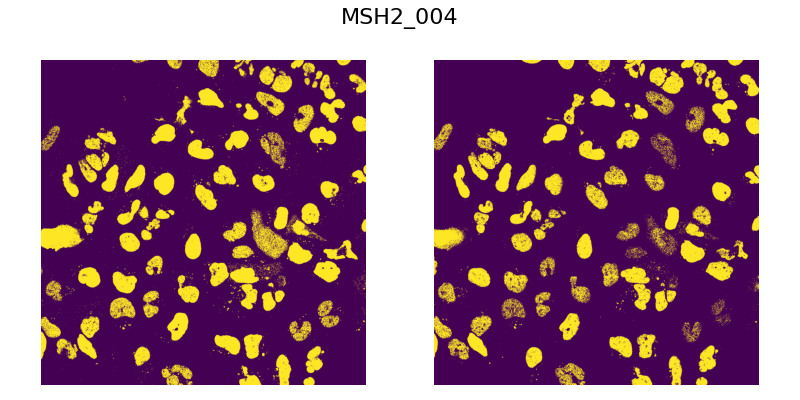

1.70GB [05:02, 6.04MB/s]


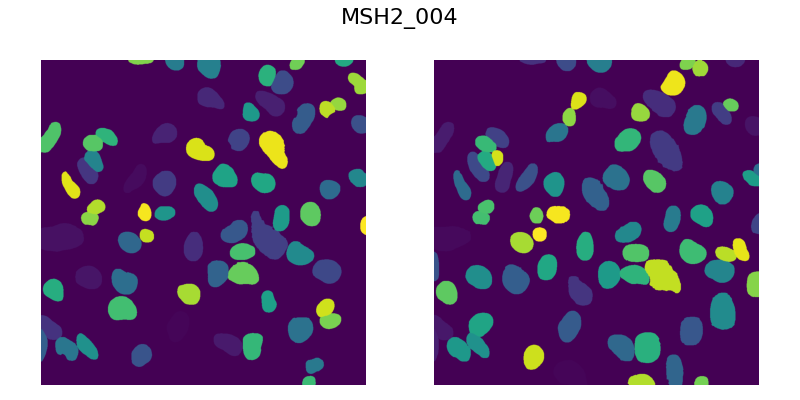

In [11]:
# Filter which experiments from the batch are processed. This can speed up iteration time while tuning the filters
# Possible values:
#     None             all experiments
#     list of numbers  [0, 2, 4] only these experiments
#     string           all experiments containing the string. E.g. 'KO' will show all experiments whose file name includes 'KO'
experiment_filter = [0]
# Which frames to process from each experiment.
# Possible values:
#     integer           1, 2, 3, etc. Evenly split the experiment interval with N points.
#                       1 will show the first frame, 2 shows the first and last frames, 3 shows first, middle, last
#     list of integers  Show the frames specified in the list, e.g. [0, 10] shows the 0th and 10th frames
frame_filter = 2
# Additionally to the final result, show the processed frames after applying these tranforms. It must be a list of integers.
# Can be indexed with negative numbers to show the result after the last transform
show_after_transform = [0, 2,3]
# The list of transforms to perform on each image before handing it to the masking algorithm.
# You can find a list of transforms with examples in transforms.ipynb
transforms = [
    # Identity transform. With 0 in show_after_transform this will show the original images.
    lambda frame: frame,
    # Convert the data format into uint8. This must be done before genereating the masks. The masking algorithm cannot handle other formats
    convert_to_u8,
    set_brightness(20),
    threshold_image(20),
]

generate_masks_using_filters_and_transforms(batch, experiment_filter, frame_filter, transforms, show_after_transform)

# Cell video generation

This part applies the transforms to all experiments in the loaded batch and runs mask generation for each frame. This can take some time. The results are saved to disk. The later stages use this data from the disk to plot the results

In [12]:
from DuckSeg.experiment_evaluator import evalute_batch
evalute_batch(batch, transforms=transforms)

Evaluating MSH2_004
Loaded from cache
Evaluating MSH2_005
Loaded from cache
Evaluating MSH2_006
Loaded from cache
Evaluating MSH2_015
Loaded from cache


# Cell video outlier filtering

In [13]:
# load segmentation results from disk

from DuckSeg.experiment_evaluator import ExperimentEvaluator

vids = []
for experiment in batch.experiments():
    print(f"Loading experiment {experiment.name}")
    exp = ExperimentEvaluator.load_experiment(experiment)
    vids += exp.cell_videos()


Loading experiment MSH2_004
Loading experiment MSH2_005
Loading experiment MSH2_006
Loading experiment MSH2_015


In [14]:
from DuckSeg.cell_video_visualizer import normalize_videos_for_display

# Sets the size of the ROI range
range_modifier = 5
vids2 = normalize_videos_for_display(vids, range_modifier=range_modifier)

In [15]:
import importlib
import DuckSeg.image_transforms

# Run this cell anytime you edit the image_transforms.py file to instantly update it!
importlib.reload(DuckSeg.image_transforms)

<module 'DuckSeg.image_transforms' from '/content/DuckSeg/src/DuckSeg/image_transforms.py'>

In [16]:
# These set the checkboxes
manual_outliers = set()

In [19]:
from DuckSeg.cell_video_visualizer import show_video_grid_jupyter
output.enable_custom_widget_manager()
batch_size = 30
updaters = []
for i in range(0, len(vids2), batch_size):
    updaters.append(show_video_grid_jupyter(vids2[i:i+batch_size], manual_outliers=manual_outliers))
update_outliers = lambda outliers, manual: [updater(outliers, manual) for updater in updaters]

In [54]:
print(f"Total automatically detected outliers: {len(outliers)}")
for outlier in sorted(list(outliers)):
    print(outlier)

Total automatically detected outliers: 163

MSH2_004_0
MSH2_004_1
MSH2_004_10
MSH2_004_11
MSH2_004_12
MSH2_004_13
MSH2_004_14
MSH2_004_15
MSH2_004_16
MSH2_004_17
MSH2_004_18
MSH2_004_19
MSH2_004_2
MSH2_004_20
MSH2_004_21
MSH2_004_22
MSH2_004_23
MSH2_004_24
MSH2_004_25
MSH2_004_26
MSH2_004_27
MSH2_004_28
MSH2_004_29
MSH2_004_3
MSH2_004_30
MSH2_004_31
MSH2_004_32
MSH2_004_33
MSH2_004_34
MSH2_004_35
MSH2_004_36
MSH2_004_37
MSH2_004_38
MSH2_004_39
MSH2_004_4
MSH2_004_40
MSH2_004_5
MSH2_004_6
MSH2_004_7
MSH2_004_8
MSH2_004_9
MSH2_005_0
MSH2_005_1
MSH2_005_10
MSH2_005_11
MSH2_005_12
MSH2_005_13
MSH2_005_14
MSH2_005_15
MSH2_005_16
MSH2_005_17
MSH2_005_18
MSH2_005_19
MSH2_005_2
MSH2_005_20
MSH2_005_21
MSH2_005_22
MSH2_005_23
MSH2_005_24
MSH2_005_25
MSH2_005_26
MSH2_005_27
MSH2_005_28
MSH2_005_29
MSH2_005_3
MSH2_005_30
MSH2_005_31
MSH2_005_32
MSH2_005_33
MSH2_005_34
MSH2_005_35
MSH2_005_36
MSH2_005_37
MSH2_005_38
MSH2_005_39
MSH2_005_4
MSH2_005_5
MSH2_005_6
MSH2_005_7
MSH2_005_8
MSH2_005_9
MSH2

In [30]:
manual_outliers

{'',
 'MSH2_004_13',
 'MSH2_004_20',
 'MSH2_004_37',
 'MSH2_004_40',
 'MSH2_005_4',
 'MSH2_005_6',
 'MSH2_006_31',
 'MSH2_015_37'}

In [31]:
from DuckSeg.outlier_filters import area_between, max_area_change_between_frames, max_total_area_change, id_starts_with
from DuckSeg.outlier_filters import outlier_vids

# copy the ids of cells here to always set them as outliers. For example {"REV7_WT_1700_001_24"}
extra_manual_outliers = {''}

filters = [
    area_between(10, 5000),
    #max_area_change_between_frames(0.2),
    #max_total_area_change(0.2),
    #id_starts_with('REV'),
]
outliers = outlier_vids(vids, extra_manual_outliers, filters)
_ = update_outliers(outliers, extra_manual_outliers)

In [32]:
outliers

{'',
 'MSH2_004_0',
 'MSH2_004_10',
 'MSH2_004_11',
 'MSH2_004_14',
 'MSH2_004_17',
 'MSH2_004_18',
 'MSH2_004_2',
 'MSH2_004_21',
 'MSH2_004_25',
 'MSH2_004_26',
 'MSH2_004_28',
 'MSH2_004_3',
 'MSH2_004_30',
 'MSH2_004_33',
 'MSH2_004_36',
 'MSH2_004_38',
 'MSH2_004_5',
 'MSH2_004_8',
 'MSH2_004_9',
 'MSH2_005_0',
 'MSH2_005_1',
 'MSH2_005_12',
 'MSH2_005_14',
 'MSH2_005_16',
 'MSH2_005_17',
 'MSH2_005_2',
 'MSH2_005_21',
 'MSH2_005_22',
 'MSH2_005_24',
 'MSH2_005_25',
 'MSH2_005_28',
 'MSH2_005_3',
 'MSH2_005_35',
 'MSH2_005_7',
 'MSH2_005_8',
 'MSH2_005_9',
 'MSH2_006_0',
 'MSH2_006_1',
 'MSH2_006_10',
 'MSH2_006_11',
 'MSH2_006_12',
 'MSH2_006_13',
 'MSH2_006_18',
 'MSH2_006_19',
 'MSH2_006_2',
 'MSH2_006_20',
 'MSH2_006_22',
 'MSH2_006_23',
 'MSH2_006_24',
 'MSH2_006_27',
 'MSH2_006_3',
 'MSH2_006_33',
 'MSH2_006_35',
 'MSH2_006_36',
 'MSH2_006_4',
 'MSH2_006_42',
 'MSH2_006_6',
 'MSH2_006_7',
 'MSH2_006_8',
 'MSH2_006_9',
 'MSH2_015_13',
 'MSH2_015_17',
 'MSH2_015_20',
 'MSH2_01

# Data evaluation and visualization

In [33]:
cell_filter = lambda vid: vid.id not in outliers and vid.id not in manual_outliers

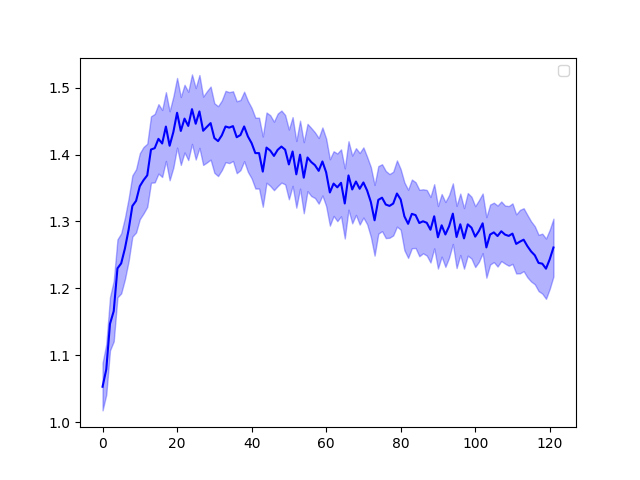

In [34]:
from DuckSeg.experiment_loader import ExperimentType
from DuckSeg.experiment_evaluator import ScoreType, plot_brightness_score_double, plot_brightness_score

plt.close('all')



_ = plot_brightness_score(
    batch,
    score_type=ScoreType.Ratio,
    range_modifier=range_modifier,
    cell_filter=cell_filter
)


In [28]:
%mkdir output

In [29]:
from DuckSeg.video_exporter import export_cell_videos
export_cell_videos(vids, os.path.join("./output/", "brightness_scores.csv"), range_modifier=range_modifier)

In [48]:
from DuckSeg.experiment_evaluator import plot_all_vid_scores
from DuckSeg.experiment_evaluator import calculate_brightness_score_for_videos, ExperimentType, ScoreType
ids, scores = calculate_brightness_score_for_videos(vids, score_type=ScoreType.Diff, range_modifier=range_modifier, cell_filter=cell_filter)
plot_all_vid_scores(scores, ids)